# Random Number Generators: Introductory Tutorial

This notebook is an introduction to random number generators for scientific computing, with an emphasis on:

- pseudo-random versus true random numbers,
- the linear congruential generator (LCG),
- famous correlation failures such as RANDU,
- Monte Carlo experiments,
- change of variables,
- histogram/PDF and empirical CDF diagnostics.

The notebook follows two rules:

- **all generator implementations and exercise solutions are written in C**, with comments and documentation,
- **all plots are made in Python with Matplotlib**.

Whenever random numbers are needed in examples, we use the **LCG introduced in the notebook**.

Main references:

- [A PRNG Shootout](https://prng.di.unimi.it/)
- [RANDOM.ORG: Introduction to Randomness and Random Numbers](https://www.random.org/randomness/)
- [David MacKay, *Information Theory, Inference, and Learning Algorithms*](https://www.inference.org.uk/mackay/itila/)

## 1. Why random numbers matter

Random numbers are a foundational tool in computational physics, statistics, and inference. They appear in:

- Monte Carlo integration,
- stochastic simulations,
- uncertainty propagation,
- Bayesian inference,
- sampling from complicated probability distributions.

In Monte Carlo we approximate expectations by sample averages:

$$
\mathbb{E}[f(X)] \approx \frac{1}{N}\sum_{i=1}^N f(X_i).
$$

This only works if the sequence behaves sufficiently like independent draws from the intended distribution. So the quality of the random number generator is part of the quality of the scientific result.

MacKay places **Monte Carlo Methods** in **Chapter 29** of *Information Theory, Inference, and Learning Algorithms*, followed by **Efficient Monte Carlo Methods** in Chapter 30. That is exactly the right perspective: random sampling is not a technical afterthought, but a core inference tool.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Use a clean plotting style suitable for lecture material.
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


def lcg_uint32(seed, n, a=1664525, c=1013904223, m=2**32):
    """Return ``n`` raw unsigned 32-bit states from the notebook LCG.

    Parameters
    ----------
    seed : int
        Initial state of the generator.
    n : int
        Number of outputs to generate.
    a, c, m : int
        LCG parameters in the recurrence ``x_{n+1} = (a x_n + c) mod m``.
    """
    # Preallocate the output array so generation is explicit and fast.
    values = np.empty(n, dtype=np.uint64)
    state = np.uint64(seed)

    # Update the internal state and store each new integer output.
    for i in range(n):
        state = (np.uint64(a) * state + np.uint64(c)) % np.uint64(m)
        values[i] = state

    return values


def lcg_uniform(seed, n, a=1664525, c=1013904223, m=2**32):
    """Return ``n`` pseudo-random numbers in the interval ``[0, 1)``.

    This is obtained by dividing the raw LCG integer outputs by the modulus.
    """
    # Reuse the integer generator and rescale to floating-point uniforms.
    return lcg_uint32(seed, n, a=a, c=c, m=m) / m


def randu_uniform(seed, n):
    """Return ``n`` uniforms produced by the historical RANDU generator.

    RANDU is intentionally included as a bad example because its outputs
    show strong geometric correlations in higher dimensions.
    """
    values = np.empty(n, dtype=np.uint64)
    state = np.uint64(seed & 0x7FFFFFFF)

    # Generate successive RANDU states modulo 2^31.
    for i in range(n):
        state = (np.uint64(65539) * state) % np.uint64(2**31)
        values[i] = state

    return values / float(2**31)


def empirical_cdf(samples):
    """Return the x and y coordinates of the empirical cumulative distribution.

    The returned arrays can be plotted directly with Matplotlib.
    """
    # Sort the sample to build the monotone empirical CDF curve.
    x = np.sort(samples)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

## 2. True randomness versus pseudo-randomness

A **true random number generator (TRNG)** extracts randomness from a physical source.
A **pseudo-random number generator (PRNG)** is a deterministic algorithm that produces a sequence that looks random.

[RANDOM.ORG](https://www.random.org/randomness/) describes its service as a **true random number service** based on **atmospheric noise**. That is useful as a conceptual benchmark:

- TRNGs are physically sourced and unpredictable,
- PRNGs are deterministic, fast, and reproducible.

For numerical simulation, reproducibility is usually a feature, not a bug. We want the same seed to give the same result so that experiments can be checked and debugged. But reproducibility is only useful if the PRNG has sufficiently weak correlations.

## 3. The LCG used in this notebook

A linear congruential generator has the form

$$
x_{n+1} = (a x_n + c) \bmod m.
$$

We convert the integer state to a floating-point number in $[0,1)$ via

$$
u_n = \frac{x_n}{m}.
$$

### C implementation

```c
#include <stdint.h>

/*
 * Simple 32-bit linear congruential generator.
 *
 * Recurrence:
 *     x_{n+1} = a x_n + c   (mod 2^32)
 *
 * This implementation is intentionally simple because the notebook
 * uses it as a teaching example and as a common source of random
 * numbers in all exercises.
 */
static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

/*
 * Return a pseudo-random double in [0,1).
 */
static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}
```

This is a useful teaching generator because it is easy to understand and implement in C. It is **not** presented as a best modern choice.

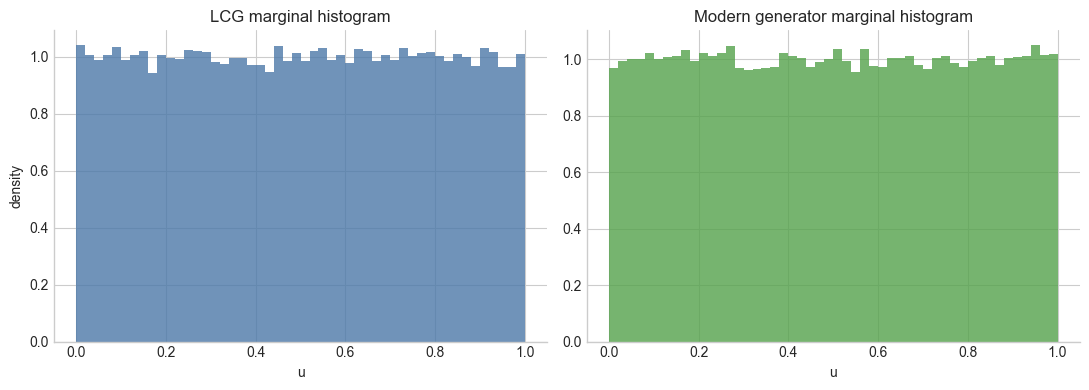

In [2]:
# Draw one-dimensional samples from the notebook LCG.
u_lcg = lcg_uniform(seed=12345, n=100000)

# Draw a comparison sample from NumPy's modern default generator.
u_good = np.random.default_rng(12345).random(100000)

# Compare only the marginal distributions.
# In one dimension the simple LCG already looks fairly uniform.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(u_lcg, bins=50, density=True, color="#4C78A8", alpha=0.8)
ax[0].set_title("LCG marginal histogram")
ax[0].set_xlabel("u")
ax[0].set_ylabel("density")

ax[1].hist(u_good, bins=50, density=True, color="#54A24B", alpha=0.8)
ax[1].set_title("Modern generator marginal histogram")
ax[1].set_xlabel("u")

plt.tight_layout()
plt.show()

In one dimension, the LCG looks harmless. This is precisely why RNG quality can be deceptive:

- a generator can look uniform in 1D,
- and still show strong hidden structure in 2D or 3D.

## 4. Correlations: the classic RANDU failure

A famous warning example is **RANDU**:

$$
x_{n+1} = 65539 x_n \bmod 2^{31}.
$$

RANDU became infamous because the triples

$$
(u_n, u_{n+1}, u_{n+2})
$$

lie on a small number of planes instead of filling 3D space smoothly.

### C implementation of RANDU

```c
#include <stdint.h>

/*
 * RANDU: historically famous, and famously bad.
 * It is included here as a warning example.
 */
static inline uint32_t randu_next(uint32_t *state) {
    *state = (65539u * (*state)) & 0x7fffffff;
    return *state;
}

static inline double randu_next_double(uint32_t *state) {
    return randu_next(state) / 2147483648.0;
}
```

In [3]:
# Generate enough values to form overlapping triples (u_n, u_{n+1}, u_{n+2}).
n = 6000
u_randu = randu_uniform(seed=1, n=n + 2)
triples_randu = np.column_stack([u_randu[:-2], u_randu[1:-1], u_randu[2:]])

# Build the same triple structure for the notebook LCG.
u_lcg_3d = lcg_uniform(seed=1, n=n + 2)
triples_lcg = np.column_stack([u_lcg_3d[:-2], u_lcg_3d[1:-1], u_lcg_3d[2:]])

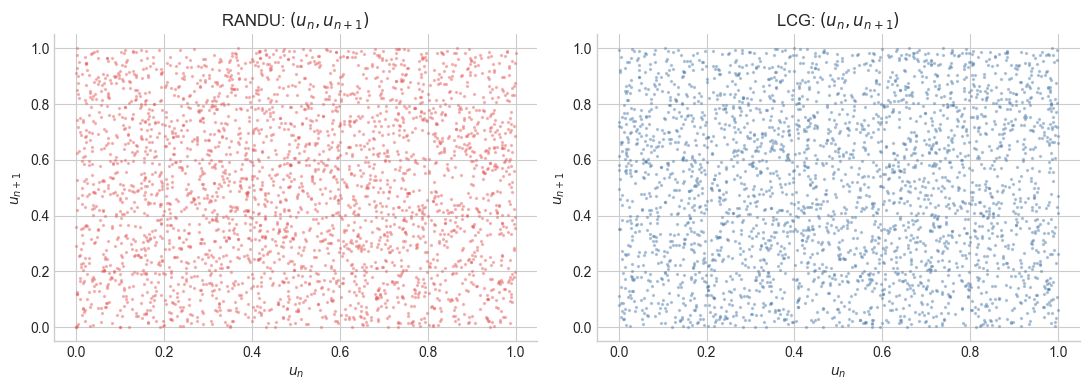

In [4]:
# A two-dimensional scatter plot already hints at serial structure.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].scatter(triples_randu[:3000, 0], triples_randu[:3000, 1], s=2, alpha=0.35, color="#E45756")
ax[0].set_title("RANDU: $(u_n, u_{n+1})$")
ax[0].set_xlabel("$u_n$")
ax[0].set_ylabel("$u_{n+1}$")

ax[1].scatter(triples_lcg[:3000, 0], triples_lcg[:3000, 1], s=2, alpha=0.35, color="#4C78A8")
ax[1].set_title("LCG: $(u_n, u_{n+1})$")
ax[1].set_xlabel("$u_n$")
ax[1].set_ylabel("$u_{n+1}$")

plt.tight_layout()
plt.show()

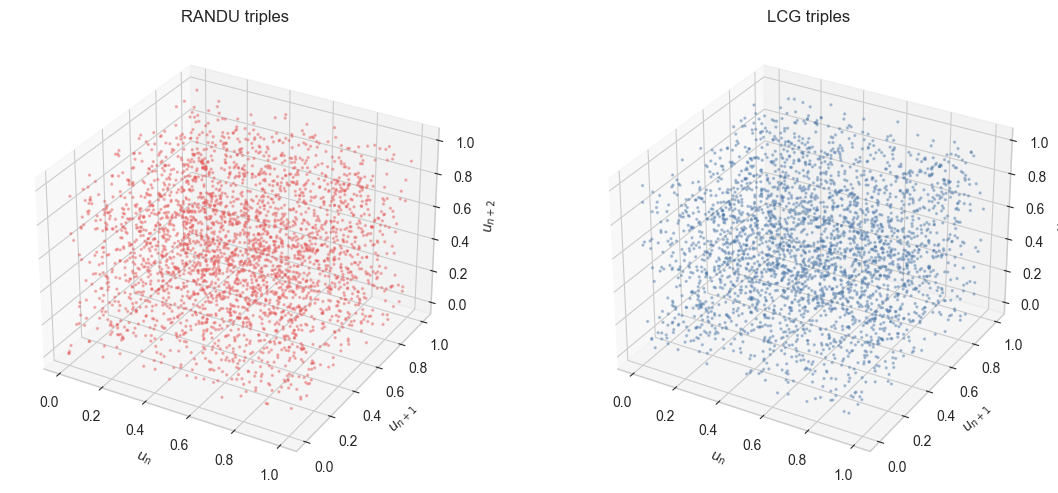

In [5]:
# The three-dimensional view is where RANDU's plane structure becomes famous.
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(triples_randu[:3000, 0], triples_randu[:3000, 1], triples_randu[:3000, 2], s=2, alpha=0.35, color="#E45756")
ax1.set_title("RANDU triples")
ax1.set_xlabel("$u_n$")
ax1.set_ylabel("$u_{n+1}$")
ax1.set_zlabel("$u_{n+2}$")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(triples_lcg[:3000, 0], triples_lcg[:3000, 1], triples_lcg[:3000, 2], s=2, alpha=0.35, color="#4C78A8")
ax2.set_title("LCG triples")
ax2.set_xlabel("$u_n$")
ax2.set_ylabel("$u_{n+1}$")
ax2.set_zlabel("$u_{n+2}$")

plt.tight_layout()
plt.show()

This is the kind of defect that matters for Monte Carlo work. The page [A PRNG Shootout](https://prng.di.unimi.it/) emphasizes that period length and speed are not enough; hidden structure and strong statistical tests matter.

## 5. Coin tosses and the Law of Large Numbers

A simple Monte Carlo experiment is a sequence of fair coin tosses. If we code

- heads = 1,
- tails = 0,

then the running average should approach $0.5$ as the number of tosses increases. This is the **Law of Large Numbers** in action.

### C code: coin tosses driven by the notebook LCG

```c
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

/*
 * Simulate coin tosses with the LCG.
 * A value < 0.5 is called heads, otherwise tails.
 * The program prints the running mean so it can be plotted later.
 */
int main(void) {
    uint32_t state = 123456789u;
    const int n = 100000;
    int heads = 0;

    for (int i = 1; i <= n; ++i) {
        double u = lcg32_next_double(&state);
        int toss = (u < 0.5) ? 1 : 0;
        heads += toss;

        printf("%d %.10f\n", i, (double)heads / i);
    }

    return 0;
}
```

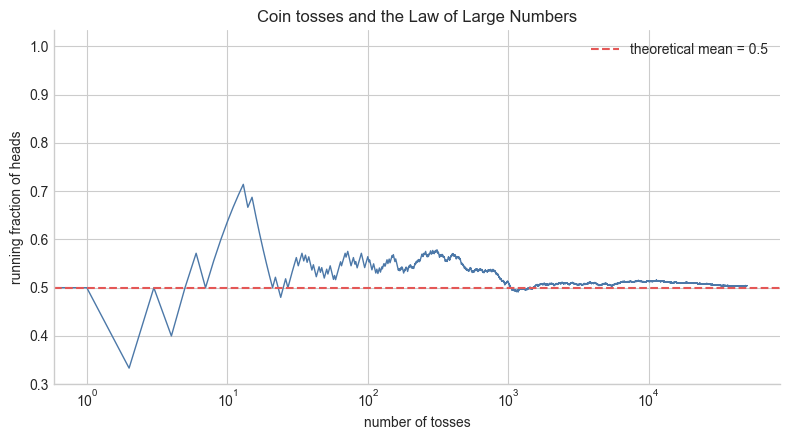

In [6]:
# Use the LCG to simulate a long sequence of fair coin tosses.
n = 50000
u = lcg_uniform(seed=123456789, n=n)

# Interpret u < 0.5 as heads and u >= 0.5 as tails.
tosses = (u < 0.5).astype(int)

# The running mean should drift toward the theoretical value 0.5.
running_mean = np.cumsum(tosses) / np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(running_mean, color="#4C78A8", linewidth=1.0)
ax.axhline(0.5, color="#E45756", linestyle="--", label="theoretical mean = 0.5")
ax.set_xscale("log")
ax.set_xlabel("number of tosses")
ax.set_ylabel("running fraction of heads")
ax.set_title("Coin tosses and the Law of Large Numbers")
ax.legend()
plt.tight_layout()
plt.show()

In Monte Carlo language, this is a toy estimator of an expectation. The key point is not the coin itself; it is the idea that a sample average approaches a population average when the sampling behaves well.

## 6. Change of variables

Change of variables is one of the most useful bridges between mathematics and random-number generation.

If $X$ has density $f_X(x)$ and $Y = g(X)$ is monotonic, then

$$
f_Y(y) = f_X\bigl(g^{-1}(y)\bigr) \left|\frac{d}{dy} g^{-1}(y)\right|.
$$

We will use the notebook LCG to generate the original uniform variable and then transform it.

### Example A: $U \sim \mathrm{Uniform}(0,1)$ and $Y = U^2$

Since $u = \sqrt{y}$ and $du/dy = 1/(2\sqrt{y})$, the transformed density is

$$
f_Y(y) = \frac{1}{2\sqrt{y}}, \qquad 0 < y \le 1.
$$

### Example B: inverse transform to get an exponential variable

If $U \sim \mathrm{Uniform}(0,1)$ and

$$
Y = -\frac{1}{\lambda}\ln(1-U),
$$

then $Y$ has exponential density

$$
f_Y(y) = \lambda e^{-\lambda y}, \qquad y \ge 0.
$$

### C code: generate both transformed variables from the LCG

```c
#include <math.h>
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

/*
 * Generate samples for two change-of-variables examples:
 *   1) y = u^2
 *   2) y = -log(1-u)/lambda
 *
 * The output can be redirected to a text file and plotted in Python.
 */
int main(void) {
    uint32_t state = 246813579u;
    const int n = 200000;
    const double lambda = 1.5;

    for (int i = 0; i < n; ++i) {
        double u = lcg32_next_double(&state);
        double y_square = u * u;
        double y_exp = -log(1.0 - u) / lambda;
        printf("%.12f %.12f %.12f\n", u, y_square, y_exp);
    }

    return 0;
}
```

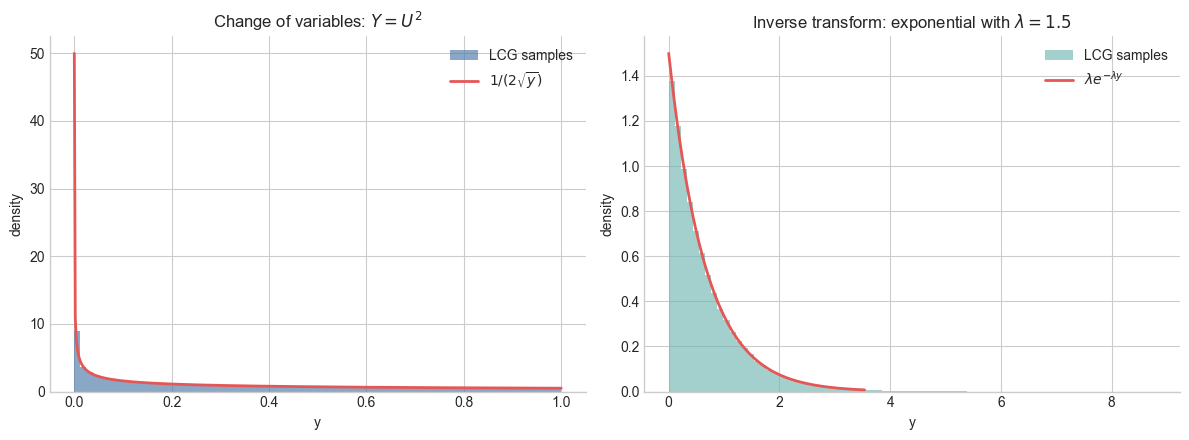

In [7]:
# Generate one uniform sample and reuse it in two change-of-variables examples.
u = lcg_uniform(seed=246813579, n=200000)

# Example A: square the uniform variable.
y_square = u**2

# Example B: inverse-transform sampling for an exponential distribution.
lam = 1.5
y_exp = -np.log(1.0 - u) / lam

# Analytic density for Y = U^2 on (0, 1].
y_grid = np.linspace(1e-4, 1.0, 500)
pdf_square = 1.0 / (2.0 * np.sqrt(y_grid))

# Analytic density for the exponential distribution.
x_grid = np.linspace(0.0, np.quantile(y_exp, 0.995), 500)
pdf_exp = lam * np.exp(-lam * x_grid)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(y_square, bins=80, density=True, alpha=0.65, color="#4C78A8", label="LCG samples")
ax[0].plot(y_grid, pdf_square, color="#E45756", linewidth=2, label=r"$1/(2\sqrt{y})$")
ax[0].set_title(r"Change of variables: $Y = U^2$")
ax[0].set_xlabel("y")
ax[0].set_ylabel("density")
ax[0].legend()

ax[1].hist(y_exp, bins=80, density=True, alpha=0.65, color="#72B7B2", label="LCG samples")
ax[1].plot(x_grid, pdf_exp, color="#E45756", linewidth=2, label=r"$\lambda e^{-\lambda y}$")
ax[1].set_title(r"Inverse transform: exponential with $\lambda=1.5$")
ax[1].set_xlabel("y")
ax[1].set_ylabel("density")
ax[1].legend()

plt.tight_layout()
plt.show()

## 7. Histogram versus PDF, and empirical CDF

A histogram is a **sample-based approximation** to a density. A PDF is an **analytic function**. They are related, but not the same thing.

An empirical CDF is often even more stable visually than a histogram because it avoids arbitrary bin choices. If $x_{(1)} \le \dots \le x_{(n)}$ are sorted samples, then the empirical CDF is

$$
\hat F_n(x_{(i)}) = \frac{i}{n}.
$$

Here we use LCG-driven exponential samples because we know the exact PDF and CDF:

$$
f(y) = \lambda e^{-\lambda y}, \qquad
F(y) = 1 - e^{-\lambda y}.
$$

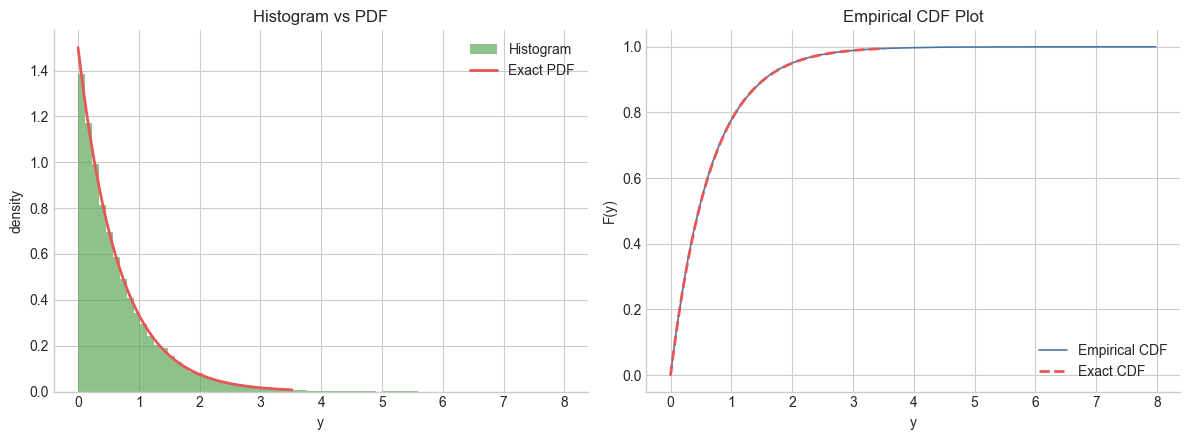

In [8]:
# Generate exponential samples from the notebook LCG via inverse transform.
lam = 1.5
u = lcg_uniform(seed=97531, n=50000)
y = -np.log(1.0 - u) / lam

# Build the exact PDF on a plotting grid.
x_pdf = np.linspace(0.0, np.quantile(y, 0.995), 500)
pdf = lam * np.exp(-lam * x_pdf)

# Build the empirical and exact CDF curves.
x_ecdf, y_ecdf = empirical_cdf(y)
x_cdf = np.linspace(0.0, np.quantile(y, 0.995), 500)
cdf = 1.0 - np.exp(-lam * x_cdf)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].hist(y, bins=70, density=True, alpha=0.65, color="#54A24B", label="Histogram")
ax[0].plot(x_pdf, pdf, color="#E45756", linewidth=2, label="Exact PDF")
ax[0].set_title("Histogram vs PDF")
ax[0].set_xlabel("y")
ax[0].set_ylabel("density")
ax[0].legend()

ax[1].plot(x_ecdf, y_ecdf, color="#4C78A8", linewidth=1.2, label="Empirical CDF")
ax[1].plot(x_cdf, cdf, color="#E45756", linestyle="--", linewidth=2, label="Exact CDF")
ax[1].set_title("Empirical CDF Plot")
ax[1].set_xlabel("y")
ax[1].set_ylabel("F(y)")
ax[1].legend()

plt.tight_layout()
plt.show()

These two views answer different questions:

- **Histogram vs PDF**: does the sample density match the expected shape?
- **Empirical CDF**: do cumulative probabilities match the theory across the range?

## 8. Monte Carlo example: estimating $\pi$

A standard Monte Carlo estimate uses points in the unit square:

$$
\pi \approx 4 \times \frac{\text{points inside the quarter circle}}{N}.
$$

This is a simple but useful reminder that Monte Carlo is integration by random sampling.

### C code using two LCG streams

```c
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

int main(void) {
    uint32_t state_x = 123u;
    uint32_t state_y = 987654321u;
    const int n = 1000000;
    int inside = 0;

    for (int i = 0; i < n; ++i) {
        double x = lcg32_next_double(&state_x);
        double y = lcg32_next_double(&state_y);
        if (x * x + y * y <= 1.0) {
            inside++;
        }
    }

    printf("pi_estimate = %.10f\n", 4.0 * inside / n);
    return 0;
}
```

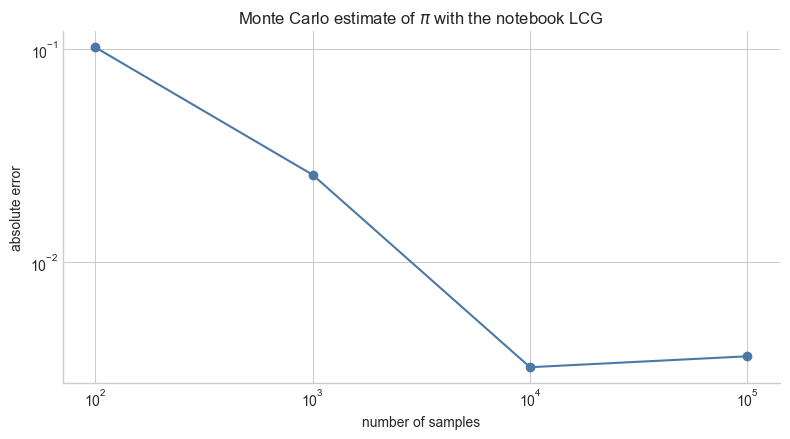

N=   100 -> pi_estimate = 3.040000
N=  1000 -> pi_estimate = 3.116000
N= 10000 -> pi_estimate = 3.138400
N=100000 -> pi_estimate = 3.138000


In [9]:
def pi_from_uniforms(u, v):
    """Estimate pi from two uniform samples in the unit square.

    The function counts how many points fall inside the quarter circle
    x^2 + y^2 <= 1 and rescales the fraction by 4.
    """
    # Points inside the quarter circle contribute to the area estimate.
    inside = (u * u + v * v) <= 1.0
    return 4.0 * inside.mean()


# Study how the Monte Carlo error changes with sample size.
sizes = np.array([10**2, 10**3, 10**4, 10**5])
pi_true = np.pi
pi_estimates = []

for n in sizes:
    # Use two LCG streams so x and y are generated independently at the code level.
    u = lcg_uniform(seed=123, n=n)
    v = lcg_uniform(seed=987654321, n=n)
    pi_estimates.append(pi_from_uniforms(u, v))

pi_estimates = np.array(pi_estimates)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(sizes, np.abs(pi_estimates - pi_true), "o-", color="#4C78A8")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of samples")
ax.set_ylabel("absolute error")
ax.set_title(r"Monte Carlo estimate of $\pi$ with the notebook LCG")
plt.tight_layout()
plt.show()

# Print the numerical estimates so students can compare values directly.
for n, est in zip(sizes, pi_estimates):
    print(f"N={n:>6d} -> pi_estimate = {est:.6f}")

The connection to MacKay Chapter 29 is direct: Monte Carlo lets us replace hard integrals by sample averages. In inference, these averages may stand for posterior expectations, marginal probabilities, or predictive quantities.

## 9. Proposed exercises

The following exercises all use the notebook LCG as the only random source.

1. **Coin tosses and LLN**  
   Generate 100,000 fair coin tosses with the LCG. Print the running fraction of heads and comment on the convergence to 0.5.

2. **Monte Carlo estimate of $\pi$**  
   Use two LCG streams to estimate $\pi$ for several sample sizes. Study how the error decreases as $N$ increases.

3. **Change of variables: $Y = U^2$**  
   Generate $U \sim \mathrm{Uniform}(0,1)$ with the LCG, transform to $Y = U^2$, and compare the histogram with the analytic density $f_Y(y)=1/(2\sqrt{y})$.

4. **Inverse transform exponential**  
   Use the formula $Y=-\ln(1-U)/\lambda$ with $\lambda=1.5$ to generate an exponential variable from the LCG output. Compare histogram and PDF.

5. **Empirical CDF**  
   For the exponential sample from Exercise 4, draw the empirical CDF and compare it to the exact CDF.

## 10. Solutions to the proposed exercises

The solutions below are intentionally written in plain C with comments, no classes, no hidden abstractions, and the same LCG in every case.

### Solution 1: coin tosses and the Law of Large Numbers

```c
#include <stdint.h>
#include <stdio.h>

/*
 * Common LCG used everywhere in the notebook.
 */
static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

int main(void) {
    uint32_t state = 123456789u;
    const int n = 100000;
    int heads = 0;

    /*
     * We print:
     *   toss_index   running_fraction_of_heads
     * so the output can be plotted externally.
     */
    for (int i = 1; i <= n; ++i) {
        double u = lcg32_next_double(&state);
        int toss = (u < 0.5) ? 1 : 0;
        heads += toss;

        printf("%d %.10f\n", i, (double)heads / i);
    }

    fprintf(stderr, "Final fraction of heads = %.10f\n", (double)heads / n);
    return 0;
}
```

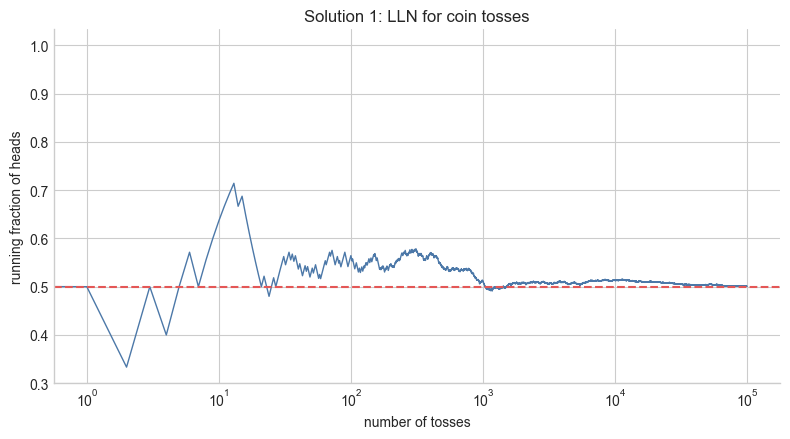

In [10]:
# Reproduce the Law of Large Numbers exercise solution with a larger sample.
n = 100000
tosses = (lcg_uniform(seed=123456789, n=n) < 0.5).astype(int)
running_fraction = np.cumsum(tosses) / np.arange(1, n + 1)

plt.figure(figsize=(8, 4.5))
plt.plot(running_fraction, color="#4C78A8", linewidth=1.0)
plt.axhline(0.5, color="#E45756", linestyle="--")
plt.xscale("log")
plt.xlabel("number of tosses")
plt.ylabel("running fraction of heads")
plt.title("Solution 1: LLN for coin tosses")
plt.tight_layout()
plt.show()

### Solution 2: Monte Carlo estimate of $\pi$

```c
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

static double estimate_pi(int n, uint32_t seed_x, uint32_t seed_y) {
    uint32_t state_x = seed_x;
    uint32_t state_y = seed_y;
    int inside = 0;

    for (int i = 0; i < n; ++i) {
        double x = lcg32_next_double(&state_x);
        double y = lcg32_next_double(&state_y);

        if (x * x + y * y <= 1.0) {
            inside++;
        }
    }

    return 4.0 * inside / n;
}

int main(void) {
    const int sizes[] = {100, 1000, 10000, 100000};
    const int n_sizes = (int)(sizeof(sizes) / sizeof(sizes[0]));

    for (int i = 0; i < n_sizes; ++i) {
        double pi_est = estimate_pi(sizes[i], 123u, 987654321u);
        printf("%d %.10f\n", sizes[i], pi_est);
    }

    return 0;
}
```

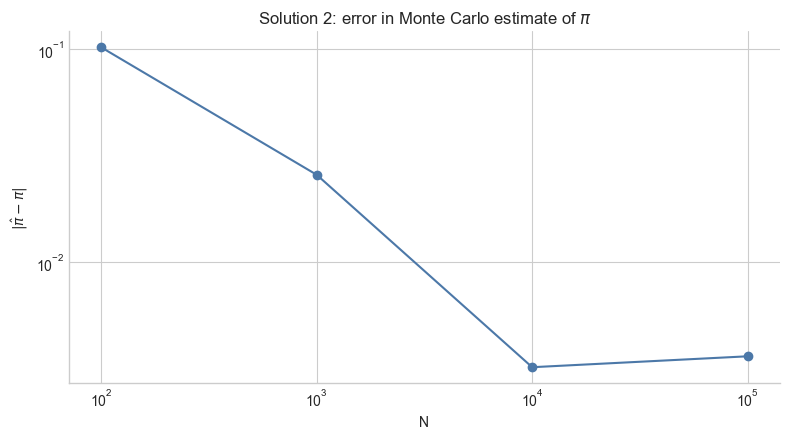

In [11]:
# Evaluate the Monte Carlo estimate of pi at several sample sizes.
sizes = np.array([100, 1000, 10000, 100000])
pi_est = []

for n in sizes:
    # Reuse the same helper function defined earlier in the notebook.
    x = lcg_uniform(seed=123, n=n)
    y = lcg_uniform(seed=987654321, n=n)
    pi_est.append(pi_from_uniforms(x, y))

pi_est = np.array(pi_est)

plt.figure(figsize=(8, 4.5))
plt.plot(sizes, np.abs(pi_est - np.pi), "o-", color="#4C78A8")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N")
plt.ylabel(r"$|\hat\pi - \pi|$")
plt.title(r"Solution 2: error in Monte Carlo estimate of $\pi$")
plt.tight_layout()
plt.show()

### Solution 3: change of variables with $Y = U^2$

```c
#include <math.h>
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

/*
 * Generate y = u^2.
 * The theoretical density is f(y) = 1 / (2 sqrt(y)) on (0,1].
 */
int main(void) {
    uint32_t state = 13579u;
    const int n = 200000;

    for (int i = 0; i < n; ++i) {
        double u = lcg32_next_double(&state);
        double y = u * u;
        printf("%.12f\n", y);
    }

    return 0;
}
```

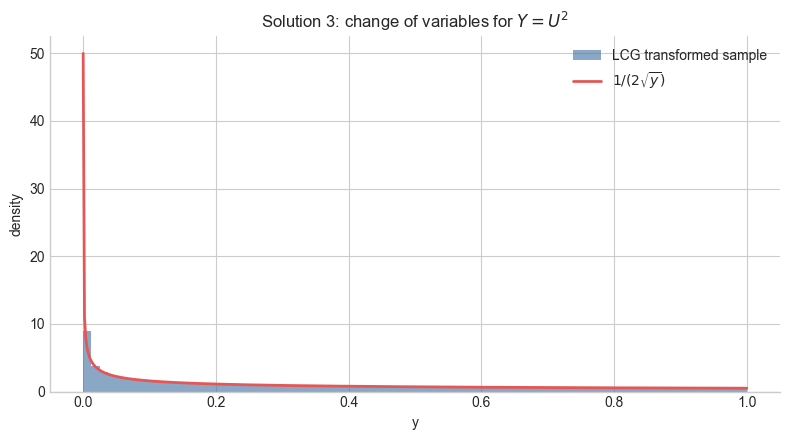

In [12]:
# Generate the transformed sample Y = U^2 from the notebook LCG.
y = lcg_uniform(seed=13579, n=200000) ** 2

# Build the analytic density predicted by change of variables.
grid = np.linspace(1e-4, 1.0, 500)
pdf = 1.0 / (2.0 * np.sqrt(grid))

plt.figure(figsize=(8, 4.5))
plt.hist(y, bins=80, density=True, alpha=0.65, color="#4C78A8", label="LCG transformed sample")
plt.plot(grid, pdf, color="#E45756", linewidth=2, label=r"$1/(2\sqrt{y})$")
plt.xlabel("y")
plt.ylabel("density")
plt.title(r"Solution 3: change of variables for $Y=U^2$")
plt.legend()
plt.tight_layout()
plt.show()

### Solution 4: inverse transform exponential

```c
#include <math.h>
#include <stdint.h>
#include <stdio.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

/*
 * Inverse-transform sampling for an exponential variable:
 *     y = -log(1-u)/lambda
 */
int main(void) {
    uint32_t state = 246813579u;
    const int n = 200000;
    const double lambda = 1.5;

    for (int i = 0; i < n; ++i) {
        double u = lcg32_next_double(&state);
        double y = -log(1.0 - u) / lambda;
        printf("%.12f\n", y);
    }

    return 0;
}
```

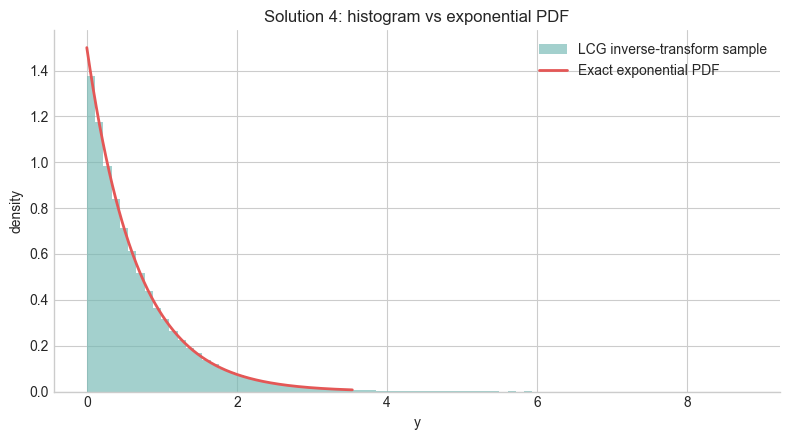

In [13]:
# Generate an exponential sample with inverse-transform sampling.
lam = 1.5
y = -np.log(1.0 - lcg_uniform(seed=246813579, n=200000)) / lam

# Plot the exact density on the same horizontal range as the histogram.
grid = np.linspace(0.0, np.quantile(y, 0.995), 500)
pdf = lam * np.exp(-lam * grid)

plt.figure(figsize=(8, 4.5))
plt.hist(y, bins=80, density=True, alpha=0.65, color="#72B7B2", label="LCG inverse-transform sample")
plt.plot(grid, pdf, color="#E45756", linewidth=2, label="Exact exponential PDF")
plt.xlabel("y")
plt.ylabel("density")
plt.title("Solution 4: histogram vs exponential PDF")
plt.legend()
plt.tight_layout()
plt.show()

### Solution 5: empirical CDF for the exponential sample

```c
#include <math.h>
#include <stdint.h>
#include <stdio.h>
#include <stdlib.h>

static inline uint32_t lcg32_next(uint32_t *state) {
    const uint32_t a = 1664525u;
    const uint32_t c = 1013904223u;
    *state = a * (*state) + c;
    return *state;
}

static inline double lcg32_next_double(uint32_t *state) {
    return lcg32_next(state) / 4294967296.0;
}

static int compare_double(const void *pa, const void *pb) {
    const double a = *(const double *)pa;
    const double b = *(const double *)pb;
    if (a < b) return -1;
    if (a > b) return 1;
    return 0;
}

int main(void) {
    uint32_t state = 246813579u;
    const int n = 50000;
    const double lambda = 1.5;
    double *sample = malloc((size_t)n * sizeof(double));

    if (sample == NULL) {
        fprintf(stderr, "Allocation failed.\n");
        return 1;
    }

    for (int i = 0; i < n; ++i) {
        double u = lcg32_next_double(&state);
        sample[i] = -log(1.0 - u) / lambda;
    }

    qsort(sample, (size_t)n, sizeof(double), compare_double);

    /*
     * Print x_i and i/n for an empirical CDF plot.
     */
    for (int i = 0; i < n; ++i) {
        printf("%.12f %.12f\n", sample[i], (double)(i + 1) / n);
    }

    free(sample);
    return 0;
}
```

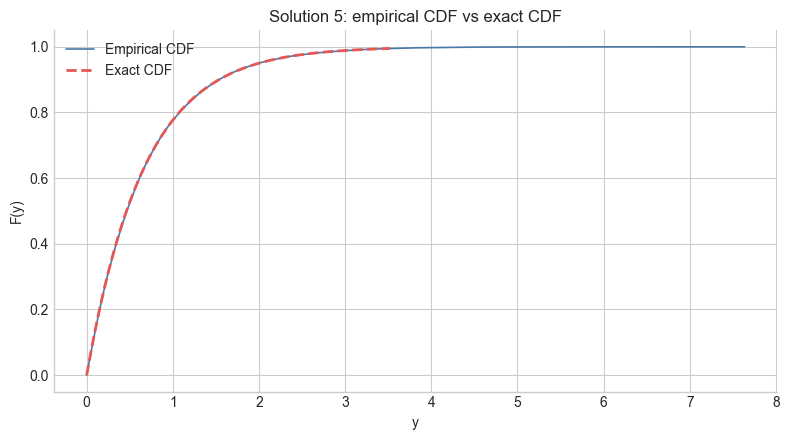

In [14]:
# Regenerate the exponential sample for the empirical CDF exercise.
lam = 1.5
y = -np.log(1.0 - lcg_uniform(seed=246813579, n=50000)) / lam

# Compute the empirical CDF from the sorted sample.
x_emp, y_emp = empirical_cdf(y)

# Compute the exact exponential CDF on a matching grid.
x_grid = np.linspace(0.0, np.quantile(y, 0.995), 500)
cdf = 1.0 - np.exp(-lam * x_grid)

plt.figure(figsize=(8, 4.5))
plt.plot(x_emp, y_emp, color="#4C78A8", linewidth=1.2, label="Empirical CDF")
plt.plot(x_grid, cdf, color="#E45756", linestyle="--", linewidth=2, label="Exact CDF")
plt.xlabel("y")
plt.ylabel("F(y)")
plt.title("Solution 5: empirical CDF vs exact CDF")
plt.legend()
plt.tight_layout()
plt.show()

## 11. Summary

The notebook shows a workflow that is common in computational science:

- implement a generator in a low-level language such as C,
- inspect its behavior with statistical ideas,
- visualize samples with Python,
- connect the generator quality to Monte Carlo reliability.

The main lesson is simple: a random number generator is not judged only by speed or by a uniform-looking histogram. Hidden correlations can matter, especially when Monte Carlo is used for inference.

## 12. References

- Sebastiano Vigna, **A PRNG Shootout**: [https://prng.di.unimi.it/](https://prng.di.unimi.it/)
- RANDOM.ORG, **Introduction to Randomness and Random Numbers**: [https://www.random.org/randomness/](https://www.random.org/randomness/)
- David J. C. MacKay, *Information Theory, Inference, and Learning Algorithms*: [https://www.inference.org.uk/mackay/itila/](https://www.inference.org.uk/mackay/itila/)

Reference notes used in the notebook:

- RANDOM.ORG distinguishes true random numbers from pseudo-random numbers and describes its service as based on atmospheric noise.
- The PRNG shootout stresses that modern generator assessment requires more than period length and speed.
- MacKay's contents page places Monte Carlo Methods in Chapter 29, tying sampling directly to inference.